## Existing Fixed Canaries (Baseline)

The FFF framework selects a seed image from a finite pool (e.g., zebra, elephant, checkerboard) and optimizes its pixels via backpropagation through a frozen YOLOv8 detector. Below are the **seed canary images** from `InitImages/`. These are the starting points — and the finite set an adaptive attacker can enumerate and defeat.

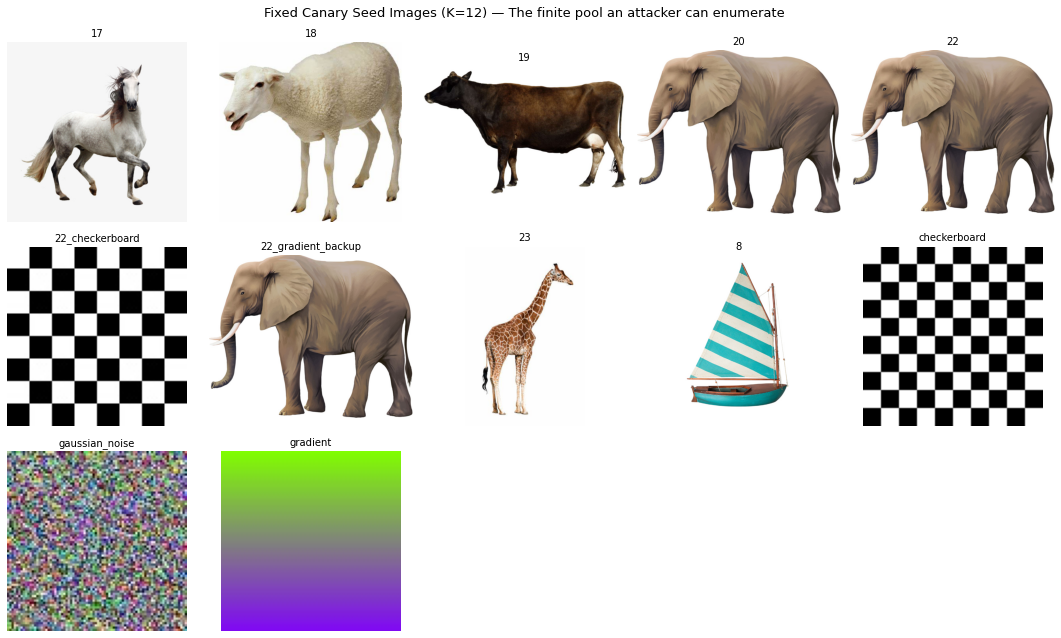

In [24]:
import os
import cv2
import matplotlib.pyplot as plt

# Path to seed canary images
init_root = '../InitImages'

# Collect all image files (skip subdirectories)
img_files = sorted([
    f for f in os.listdir(init_root)
    if f.lower().endswith(('.jpg', '.jpeg', '.png')) and os.path.isfile(os.path.join(init_root, f))
])

n = len(img_files)
cols = min(n, 5)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
if rows == 1:
    axes = [axes] if n == 1 else list(axes)
else:
    axes = list(axes.flat)

for i, fname in enumerate(img_files):
    img = cv2.imread(os.path.join(init_root, fname))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    name = os.path.splitext(fname)[0]
    axes[i].set_title(name, fontsize=10)
    axes[i].axis('off')

for j in range(n, len(axes)):
    axes[j].axis('off')

fig.suptitle(f'Fixed Canary Seed Images (K={n}) — The finite pool an attacker can enumerate', fontsize=13)
plt.tight_layout()
plt.show()

## Training a Fixed Canary (Class 17 — Horse)

Below we train a **fixed canary** using the existing FFF pipeline as a baseline. The canary is initialized from `InitImages/17.jpg` (horse) and optimized for 50 epochs with:
- Loss: $\mathcal{L} = 2.0 \cdot \mathcal{L}_{benign} - \mathcal{L}_{adv}$
- Optimizer: Adam, lr=1e-3, batch size=5
- Detector: Frozen YOLOv8n

After training, we evaluate on the 3 test images in `hady_test_samples/`:
- `sample.jpg` — benign (no attack) → expect **no attack detected**
- `sample_adv.jpg` — single person with adversarial patch → expect **attack detected**
- `sample2.jpg` — multiple people with adversarial patches → expect **attack detected**

Found trained canary at ./canary_cls17_training\canary_050.png — skipping training.
Set retrain_from_scratch = True to force retrain.



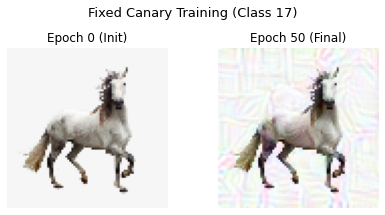


--- Evaluation on hady_test_samples ---
Load canary(17) for eval: ./canary_cls17_training\canary_050.png
  sample.jpg: is_attack = False
  sample2.jpg: is_attack = True
  sample_adv.jpg: is_attack = True


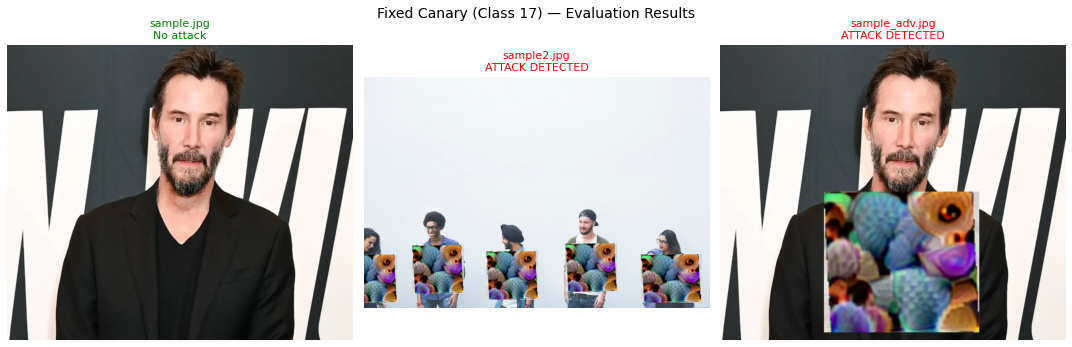

In [25]:
import sys
import os
import cv2
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
from types import SimpleNamespace

# Add parent directory to path so we can import from the FFF codebase
sys.path.insert(0, os.path.abspath('..'))

from YOLOv8_Combiner import Canary, freeze_seed
from ObjectDetector.fjn_yolov8 import FJN_YOLOv8 as YOLOv8

# ---- Configuration ----
retrain_from_scratch = False  # True = retrain even if canary already exists

cfg = SimpleNamespace(
    canary_cls_id=17,
    canary_size=80,
    canary_init=True,
    canary_init_path='../InitImages/',
    weight=2.0,
    epoch=50,
    learing_rate=1e-3,
    epoch_save=10,
    batch_size=5,
    benign_root='../Data/traineval/VOC07_YOLOv8/train_120/benign',
    benign_label_root='../Data/traineval/VOC07_YOLOv8/train_120/benign_label',
    adversarial_root='../Data/traineval/VOC07_YOLOv8/train_120/adversarial',
    data_name='VOC07_120',
    img_size=640,
    person_conf=0.05,
    overlap_thresh=0.4,
    defensive_patch_location='cc',
    eval_no_overlap=True,
    margin_size=0,
    faster=False,
    num_works=0,
    seed=301,
    detect_name='yolov8',
    attack_name='fool',
)

save_dir = './canary_cls17_training'
final_canary_path = os.path.join(save_dir, f'canary_{str(cfg.epoch).zfill(3)}.png')

# ---- Skip training if already done ----
if os.path.exists(final_canary_path) and not retrain_from_scratch:
    print(f"Found trained canary at {final_canary_path} — skipping training.")
    print("Set retrain_from_scratch = True to force retrain.\n")
else:
    if retrain_from_scratch and os.path.exists(save_dir):
        import shutil
        shutil.rmtree(save_dir)
        print(f"Cleared {save_dir}/")

    freeze_seed(cfg.seed)
    print("Loading YOLOv8 detector...")
    detector = YOLOv8()

    canary = Canary(cfg, detector)
    canary.init_dataloader()
    canary.init_canary()

    canary.canary_save_path = save_dir
    os.makedirs(save_dir, exist_ok=True)
    canary.save_canary(0)

    print(f"Training for {cfg.epoch} epochs, batch_size={cfg.batch_size}, lr={cfg.learing_rate}, weight={cfg.weight}")
    canary.train()
    print("Training complete!")
    detector.model.eval()

# ---- Show initial vs final canary ----
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
init_img = cv2.imread(os.path.join(save_dir, 'canary_000.png'))
init_img = cv2.cvtColor(init_img, cv2.COLOR_BGR2RGB)
axes[0].imshow(init_img)
axes[0].set_title('Epoch 0 (Init)')
axes[0].axis('off')

final_img = cv2.imread(final_canary_path)
final_img = cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB)
axes[1].imshow(final_img)
axes[1].set_title(f'Epoch {cfg.epoch} (Final)')
axes[1].axis('off')

fig.suptitle(f'Fixed Canary Training (Class {cfg.canary_cls_id})', fontsize=13)
plt.tight_layout()
plt.show()

# ---- Evaluate on hady_test_samples ----
print("\n--- Evaluation on hady_test_samples ---")
if 'detector' not in dir() or 'detector' not in locals():
    detector = YOLOv8()
detector.model.eval()

canary_eval = Canary(cfg, detector)
canary_eval.eval_load_canary(canary_path=final_canary_path, canary_cls_id=cfg.canary_cls_id)

test_dir = '../hady_test_samples'
test_images = sorted(os.listdir(test_dir))

fig, axes = plt.subplots(1, len(test_images), figsize=(5 * len(test_images), 5))
if len(test_images) == 1:
    axes = [axes]

for i, fname in enumerate(test_images):
    img_path = os.path.join(test_dir, fname)
    img_cv = cv2.imread(img_path, 1)
    is_attack = canary_eval.eval_single(img_cv)

    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    result_text = "ATTACK DETECTED" if is_attack else "No attack"
    color = 'red' if is_attack else 'green'
    axes[i].set_title(f'{fname}\n{result_text}', fontsize=11, color=color)
    axes[i].axis('off')
    print(f"  {fname}: is_attack = {is_attack}")

fig.suptitle('Fixed Canary (Class 17) — Evaluation Results', fontsize=14)
plt.tight_layout()
plt.show()

# Generative Canary Defense for Object Detectors

## Motivation

The original **Fight Fire with Fire (FFF)** framework defends object detectors against adversarial patch attacks by inserting fixed "canary" patches (e.g., a zebra image) near suppressed bounding boxes. If the detector fails to see the canary, an adversarial attack is detected.

**Problem:** A fixed pool of K canaries is vulnerable to adaptive attackers who can optimize a single adversarial patch to suppress all K canaries simultaneously.

**Our extension:** Replace the fixed canary with a lightweight **generator network** $G_\theta(z, b)$ that produces a **unique** 80x80x3 canary patch for every image at inference time. The attacker can never predict which canary will appear.

## Generator Architecture (~200K parameters)

**Input:** $z = [\eta \| b] \in \mathbb{R}^{36}$ where:
- $\eta \sim \mathcal{N}(0, I_{32})$ — 32-dim random noise
- $b = (x_1, y_1, x_2, y_2)_{\text{normalized}}$ — bounding box coordinates

**Layers:**
1. FC: 36 → 256, ReLU
2. FC: 256 → 512, ReLU
3. FC: 512 → 1024, ReLU
4. Reshape to 16 x 8 x 8
5. ConvTranspose2d: 16 → 8, kernel 4, stride 2, pad 1 → 8 x 16 x 16
6. ConvTranspose2d: 8 → 3, kernel 4, stride 2, pad 1 → 3 x 32 x 32
7. Sigmoid activation → pixels in [0, 1]
8. Bilinear interpolation → final 80 x 80 patch

Using device: cuda
Generator parameters: 668,811


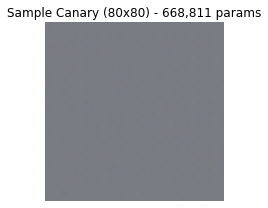

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


class GenerativeCanary(nn.Module):
    """Lightweight generator that produces unique 80x80x3 canary patches.
    
    Input:  z = [eta || b] in R^36
            eta ~ N(0, I_32)  (random noise)
            b = (x1, y1, x2, y2)  (normalized bbox coords)
    Output: canary patch of shape (3, 80, 80) with pixels in [0, 1]
    """

    def __init__(self, z_dim=32, bbox_dim=4, canary_size=80):
        super().__init__()
        self.z_dim = z_dim
        self.bbox_dim = bbox_dim
        self.canary_size = canary_size
        input_dim = z_dim + bbox_dim  # 36

        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 1024),
            nn.ReLU(inplace=True),
        )

        # Transposed convolution layers
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(16, 8, kernel_size=4, stride=2, padding=1),  # 8x8 -> 16x16
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(8, 3, kernel_size=4, stride=2, padding=1),   # 16x16 -> 32x32
            nn.Sigmoid(),
        )

    def forward(self, z):
        """Generate canary patch(es).
        
        Args:
            z: (batch, 36) concatenated [noise | bbox_coords]
        Returns:
            canary: (batch, 3, 80, 80) pixel values in [0, 1]
        """
        x = self.fc(z)                # (batch, 1024)
        x = x.view(-1, 16, 8, 8)     # (batch, 16, 8, 8)
        x = self.deconv(x)            # (batch, 3, 32, 32)
        # Bilinear interpolation to target size
        x = F.interpolate(x, size=(self.canary_size, self.canary_size), mode='bilinear', align_corners=False)
        return x


# --- Generate and display a sample canary ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

generator = GenerativeCanary().to(device)
num_params = sum(p.numel() for p in generator.parameters())
print(f'Generator parameters: {num_params:,}')

# Sample random noise + fake bbox coords
eta = torch.randn(1, 32, device=device)           # random noise
bbox = torch.tensor([[0.3, 0.4, 0.5, 0.8]], device=device)  # normalized bbox
z = torch.cat([eta, bbox], dim=1)                  # (1, 36)

with torch.no_grad():
    canary = generator(z)  # (1, 3, 80, 80)

# Display
canary_img = canary[0].cpu().permute(1, 2, 0).numpy()  # (80, 80, 3)
plt.figure(figsize=(3, 3))
plt.imshow(canary_img)
plt.title(f'Sample Canary (80x80) - {num_params:,} params')
plt.axis('off')
plt.tight_layout()
plt.show()

## On-the-Fly Canary: Generate → Train → Evaluate

This cell connects the generative canary to the existing FFF training pipeline:

1. **Generate**: The `GenerativeCanary` network produces a random 80x80 canary from a sampled $z = [\eta \| b]$
2. **Save**: The generated image is saved to `on_the_fly_canary/` as the seed init image
3. **Train**: The FFF pipeline picks it up and optimizes its pixels for 50 epochs (same as the fixed canary baseline)
4. **Evaluate**: The trained canary is tested on `hady_test_samples/`

Set `retrain_from_scratch = True` to wipe the folder and regenerate + retrain everything from scratch.

Found trained canary at ./on_the_fly_canary\training\canary_050.png — skipping generation & training.
Set retrain_from_scratch = True to redo everything.


=== Step 3: Seed vs Trained Canary ===


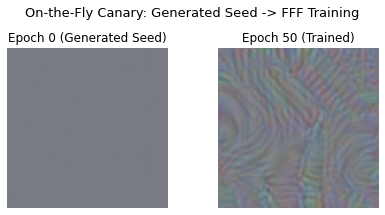


=== Step 4: Evaluation on hady_test_samples ===
Load canary(22) for eval: ./on_the_fly_canary\training\canary_050.png
  sample.jpg: is_attack = False
  sample2.jpg: is_attack = True
  sample_adv.jpg: is_attack = True


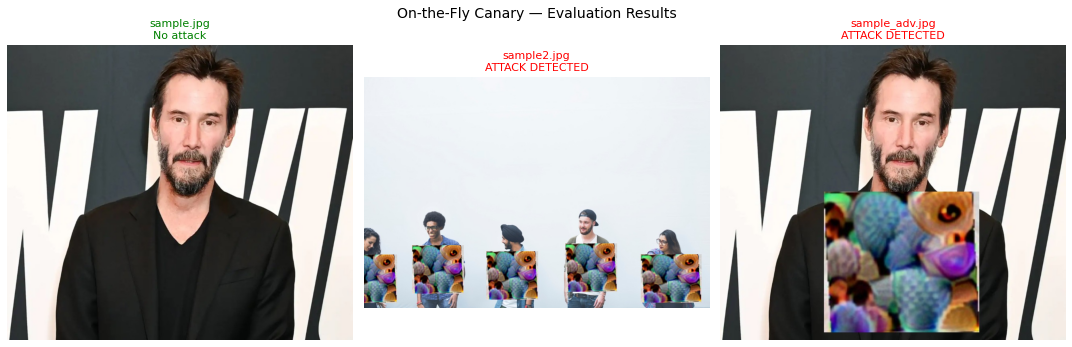

In [27]:
import sys, os, shutil, cv2, torch, numpy as np, random
import matplotlib.pyplot as plt
from types import SimpleNamespace

sys.path.insert(0, os.path.abspath('..'))
from YOLOv8_Combiner import Canary, freeze_seed
from ObjectDetector.fjn_yolov8 import FJN_YOLOv8 as YOLOv8

# =============================================
#  FLAGS
# =============================================
retrain_from_scratch = False  # True = wipe on_the_fly_canary/ and redo everything
canary_cls_id = 22            # COCO class the detector will look for

# =============================================
#  PATHS
# =============================================
work_dir = './on_the_fly_canary'
init_dir = os.path.join(work_dir, 'init')
train_dir = os.path.join(work_dir, 'training')
final_canary_name = 'canary_050.png'
final_canary_path = os.path.join(train_dir, final_canary_name)

# =============================================
#  STEP 0: Clean slate if retrain_from_scratch
# =============================================
if retrain_from_scratch and os.path.exists(work_dir):
    shutil.rmtree(work_dir)
    print(f"Cleared {work_dir}/")

os.makedirs(init_dir, exist_ok=True)
os.makedirs(train_dir, exist_ok=True)

# =============================================
#  STEP 1 & 2: Generate + Train (skip if already done)
# =============================================
already_trained = os.path.exists(final_canary_path)

if already_trained and not retrain_from_scratch:
    print(f"Found trained canary at {final_canary_path} — skipping generation & training.")
    print("Set retrain_from_scratch = True to redo everything.\n")
else:
    # --- Step 1: Generate seed ---
    print("=== Step 1: Generating seed canary with GenerativeCanary ===")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    generator = GenerativeCanary().to(device)

    eta = torch.randn(1, 32, device=device)
    bbox = torch.tensor([[0.3, 0.4, 0.5, 0.8]], device=device)
    z = torch.cat([eta, bbox], dim=1)

    with torch.no_grad():
        canary_tensor = generator(z)

    canary_np = (canary_tensor[0].cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    canary_bgr = cv2.cvtColor(canary_np, cv2.COLOR_RGB2BGR)
    seed_path = os.path.join(init_dir, f'{canary_cls_id}.jpg')
    cv2.imwrite(seed_path, canary_bgr)
    print(f"  Saved generated seed to {seed_path}")

    plt.figure(figsize=(2.5, 2.5))
    plt.imshow(canary_np)
    plt.title('Generated Seed Canary')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # --- Step 2: Train ---
    print("\n=== Step 2: Training with FFF pipeline (50 epochs) ===")
    freeze_seed(301)

    cfg = SimpleNamespace(
        canary_cls_id=canary_cls_id, canary_size=80, canary_init=True,
        canary_init_path=init_dir, weight=2.0, epoch=50, learing_rate=1e-3,
        epoch_save=10, batch_size=5,
        benign_root='../Data/traineval/VOC07_YOLOv8/train_120/benign',
        benign_label_root='../Data/traineval/VOC07_YOLOv8/train_120/benign_label',
        adversarial_root='../Data/traineval/VOC07_YOLOv8/train_120/adversarial',
        data_name='VOC07_120', img_size=640, person_conf=0.05, overlap_thresh=0.4,
        defensive_patch_location='cc', eval_no_overlap=True, margin_size=0,
        faster=False, num_works=0, seed=301, detect_name='yolov8', attack_name='fool',
    )

    detector = YOLOv8()
    canary = Canary(cfg, detector)
    canary.init_dataloader()
    canary.init_canary()
    canary.canary_save_path = train_dir
    canary.save_canary(0)
    canary.train()
    print("Training complete!")
    detector.model.eval()

# =============================================
#  STEP 3: Show seed vs trained result
# =============================================
print("\n=== Step 3: Seed vs Trained Canary ===")
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

seed_img = cv2.imread(os.path.join(train_dir, 'canary_000.png'))
seed_img = cv2.cvtColor(seed_img, cv2.COLOR_BGR2RGB)
axes[0].imshow(seed_img)
axes[0].set_title('Epoch 0 (Generated Seed)')
axes[0].axis('off')

final_img = cv2.imread(final_canary_path)
final_img = cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB)
axes[1].imshow(final_img)
axes[1].set_title('Epoch 50 (Trained)')
axes[1].axis('off')

fig.suptitle('On-the-Fly Canary: Generated Seed -> FFF Training', fontsize=13)
plt.tight_layout()
plt.show()

# =============================================
#  STEP 4: Evaluate on hady_test_samples
# =============================================
print("\n=== Step 4: Evaluation on hady_test_samples ===")

# Load detector fresh if we skipped training (no detector in scope)
try:
    detector.model.eval()
except NameError:
    detector = YOLOv8()
    detector.model.eval()

eval_cfg = SimpleNamespace(
    canary_cls_id=canary_cls_id, canary_size=80, img_size=640,
    person_conf=0.05, overlap_thresh=0.4, defensive_patch_location='cc',
    eval_no_overlap=True, margin_size=0, faster=False,
)

canary_eval = Canary(eval_cfg, detector)
canary_eval.eval_load_canary(canary_path=final_canary_path, canary_cls_id=canary_cls_id)

test_dir = '../hady_test_samples'
test_images = sorted(os.listdir(test_dir))

fig, axes = plt.subplots(1, len(test_images), figsize=(5 * len(test_images), 5))
if len(test_images) == 1:
    axes = [axes]

for i, fname in enumerate(test_images):
    img_path = os.path.join(test_dir, fname)
    img_cv = cv2.imread(img_path, 1)
    is_attack = canary_eval.eval_single(img_cv)

    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    result_text = "ATTACK DETECTED" if is_attack else "No attack"
    color = 'red' if is_attack else 'green'
    axes[i].set_title(f'{fname}\n{result_text}', fontsize=11, color=color)
    axes[i].axis('off')
    print(f"  {fname}: is_attack = {is_attack}")

fig.suptitle('On-the-Fly Canary — Evaluation Results', fontsize=14)
plt.tight_layout()
plt.show()

## Full VOC07 Evaluation: Fixed Canary vs On-the-Fly Canary

We evaluate both trained canaries on the full VOC07 test set across all 4 attack types:
- **AdvPatch** (376 adv + 376 benign images)
- **UPC** (73 + 73)
- **TCEGA** (95 + 95)
- **Natural** (205 + 205)

For each image we run `eval_single()` and classify:
- Adversarial image: `is_attack=True` → TP, `False` → FN
- Benign image: `is_attack=True` → FP, `False` → TN

Metrics: **F1** = 2PR/(P+R), **FPR** = FP/(FP+TN)

Results are compared against the paper baseline and our Level B reproduction.

In [28]:
import sys, os, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from types import SimpleNamespace
from tqdm import tqdm
from IPython.display import display, HTML

sys.path.insert(0, os.path.abspath('..'))
from YOLOv8_Combiner import Canary
from ObjectDetector.fjn_yolov8 import FJN_YOLOv8 as YOLOv8

# =============================================
#  Reusable evaluation function
# =============================================
def evaluate_canary_full(canary_obj, test_root, attacks):
    results = {}
    for attack in attacks:
        adv_dir = os.path.join(test_root, attack, 'adversarial')
        ben_dir = os.path.join(test_root, attack, 'benign')
        TP, FP, FN, TN = 0, 0, 0, 0

        adv_files = sorted([f for f in os.listdir(adv_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        for fname in tqdm(adv_files, desc=f'{attack} adv', leave=False):
            img = cv2.imread(os.path.join(adv_dir, fname), 1)
            if canary_obj.eval_single(img): TP += 1
            else: FN += 1

        ben_files = sorted([f for f in os.listdir(ben_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        for fname in tqdm(ben_files, desc=f'{attack} ben', leave=False):
            img = cv2.imread(os.path.join(ben_dir, fname), 1)
            if canary_obj.eval_single(img): FP += 1
            else: TN += 1

        P = TP / (TP + FP) if (TP + FP) > 0 else 0
        R = TP / (TP + FN) if (TP + FN) > 0 else 0
        F1 = 2 * P * R / (P + R) if (P + R) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
        results[attack] = {'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
                           'Precision': P, 'Recall': R, 'F1': F1, 'FPR': FPR}
        print(f"  {attack:10s}  F1={F1:.3f}  FPR={FPR:.3f}  (TP={TP} FP={FP} FN={FN} TN={TN})")
    return results


def styled_comparison_table(all_results, paper_baseline):
    """Build and display a styled HTML comparison table."""
    attacks = list(paper_baseline.keys())

    # Build dataframe
    rows = []
    for attack in attacks:
        row = {'Attack': attack, 'Paper F1': paper_baseline[attack]}
        for name, results in all_results.items():
            r = results[attack]
            row[f'{name} F1'] = r['F1']
            row[f'{name} FPR'] = r['FPR']
        # Delta: on-the-fly vs paper
        otf_key = [k for k in all_results.keys() if 'Fly' in k][0]
        delta = all_results[otf_key][attack]['F1'] - paper_baseline[attack]
        row['Delta'] = delta
        rows.append(row)

    df = pd.DataFrame(rows).set_index('Attack')

    # Style function
    def color_f1(val):
        if isinstance(val, float) and val >= 0.90:
            return 'background-color: #c6efce; color: #006100; font-weight: bold'
        elif isinstance(val, float) and val >= 0.85:
            return 'background-color: #ffeb9c; color: #9c5700'
        return ''

    def color_fpr(val):
        if isinstance(val, float) and val <= 0.05:
            return 'background-color: #c6efce; color: #006100; font-weight: bold'
        elif isinstance(val, float) and val <= 0.10:
            return 'background-color: #ffeb9c; color: #9c5700'
        return ''

    def color_delta(val):
        if isinstance(val, float) and val > 0:
            return 'background-color: #c6efce; color: #006100; font-weight: bold'
        elif isinstance(val, float) and val < 0:
            return 'background-color: #ffc7ce; color: #9c0006; font-weight: bold'
        return ''

    # Format
    fmt = {'Paper F1': '{:.3f}'}
    for name in all_results.keys():
        fmt[f'{name} F1'] = '{:.3f}'
        fmt[f'{name} FPR'] = '{:.3f}'
    fmt['Delta'] = '{:+.3f}'

    styled = (df.style
              .format(fmt)
              .applymap(color_f1, subset=[c for c in df.columns if 'F1' in c and 'Delta' not in c])
              .applymap(color_fpr, subset=[c for c in df.columns if 'FPR' in c])
              .applymap(color_delta, subset=['Delta'])
              .set_caption('Mode #1 (Canary) — Three-Way Comparison on YOLOv8 / VOC07')
              .set_table_styles([
                  {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
                  {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('padding', '8px 12px'), ('text-align', 'center')]},
                  {'selector': 'td', 'props': [('padding', '6px 12px'), ('text-align', 'center')]},
                  {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f8f9fa')]},
                  {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('margin', '10px 0'), ('font-family', 'Segoe UI, Arial, sans-serif')]},
                  {'selector': 'th, td', 'props': [('border', '1px solid #dee2e6')]},
              ]))

    display(styled)
    return df


# =============================================
#  Configuration
# =============================================
test_root = '../Data/testeval/VOC07_YOLOv8/test'
attacks = ['AdvPatch', 'UPC', 'TCEGA', 'Natural']
paper_baseline = {'AdvPatch': 0.974, 'UPC': 0.936, 'TCEGA': 0.807, 'Natural': 0.871}

fixed_canary_path = './canary_cls17_training/canary_050.png'
otf_canary_path = './on_the_fly_canary/training/canary_050.png'

# =============================================
#  Load detector once
# =============================================
print("Loading YOLOv8 detector...")
detector = YOLOv8()
detector.model.eval()

eval_cfg_17 = SimpleNamespace(
    canary_cls_id=17, canary_size=80, img_size=640,
    person_conf=0.05, overlap_thresh=0.4, defensive_patch_location='cc',
    eval_no_overlap=True, margin_size=0, faster=False,
)
eval_cfg_22 = SimpleNamespace(
    canary_cls_id=22, canary_size=80, img_size=640,
    person_conf=0.05, overlap_thresh=0.4, defensive_patch_location='cc',
    eval_no_overlap=True, margin_size=0, faster=False,
)

all_results = {}

# =============================================
#  Evaluate Fixed Canary (Class 17)
# =============================================
print("\n========== Fixed Canary (Class 17 - Horse) ==========")
canary_fixed = Canary(eval_cfg_17, detector)
canary_fixed.eval_load_canary(canary_path=fixed_canary_path, canary_cls_id=17)
all_results['Fixed (cls17)'] = evaluate_canary_full(canary_fixed, test_root, attacks)

# =============================================
#  Evaluate On-the-Fly Canary (Class 22)
# =============================================
print("\n========== On-the-Fly Canary (Generated + Trained) ==========")
canary_otf = Canary(eval_cfg_22, detector)
canary_otf.eval_load_canary(canary_path=otf_canary_path, canary_cls_id=22)
all_results['On-the-Fly'] = evaluate_canary_full(canary_otf, test_root, attacks)

# =============================================
#  Display styled comparison table
# =============================================
print()
df = styled_comparison_table(all_results, paper_baseline)

YOLOv8n summary (fused): 168 layers, 3151904 parameters, 0 gradients, 8.7 GFLOPs


Loading YOLOv8 detector...

========== Fixed Canary (Class 17 - Horse) ==========
Load canary(17) for eval: ./canary_cls17_training/canary_050.png


  AdvPatch    F1=0.935  FPR=0.082  (TP=357 FP=31 FN=19 TN=345)


  UPC         F1=0.877  FPR=0.123  (TP=64 FP=9 FN=9 TN=64)


  TCEGA       F1=0.896  FPR=0.116  (TP=86 FP=11 FN=9 TN=84)


...

  AdvPatch    F1=0.939  FPR=0.106  (TP=368 FP=40 FN=8 TN=336)


  UPC         F1=0.934  FPR=0.110  (TP=71 FP=8 FN=2 TN=65)


  TCEGA       F1=0.925  FPR=0.126  (TP=92 FP=12 FN=3 TN=83)


  Natural     F1=0.930  FPR=0.078  (TP=192 FP=16 FN=13 TN=189)



,Paper F1,Fixed (cls17) F1,Fixed (cls17) FPR,On-the-Fly F1,On-the-Fly FPR,Delta
Attack,,,,,,
AdvPatch,0.974,0.935,0.082,0.939,0.106,-0.035
UPC,0.936,0.877,0.123,0.934,0.110,-0.002
TCEGA,0.807,0.896,0.116,0.925,0.126,+0.118
Natural,0.871,0.900,0.078,0.930,0.078,+0.059


## Extension 1: True Generative Canary Training

This is the **real contribution**. Instead of optimizing a fixed image's pixels, we train the **generator weights** directly through the frozen YOLOv8 detector.

**Training (each batch):**
1. Sample fresh z with random noise + bbox
2. Generator produces canary: c = G(z) -- shape (3, 80, 80)
3. Paste c into benign + adversarial images (same placement as FFF)
4. Compute loss through frozen YOLOv8: L = 2.0 * L_benign - L_adv
5. loss.backward() flows: YOLOv8 --> pasted canary pixels --> generator weights
6. optimizer.step() updates the generator (not pixels, not YOLOv8)

**After training:** The generator IS the defense. Sample any z, get a unique trained canary instantly. Infinite canaries from ~200K parameters.

**At evaluation:** Each test image gets a **fresh, unique canary** -- the attacker can never predict which one.

Found final checkpoint at ./generative_canary_training\checkpoints\generator_epoch_050.pt -- skipping training.
Set retrain_from_scratch = True to force retrain.

Loaded trained generator (epoch 50)

=== Trained Generator: 8 Diverse Canaries ===


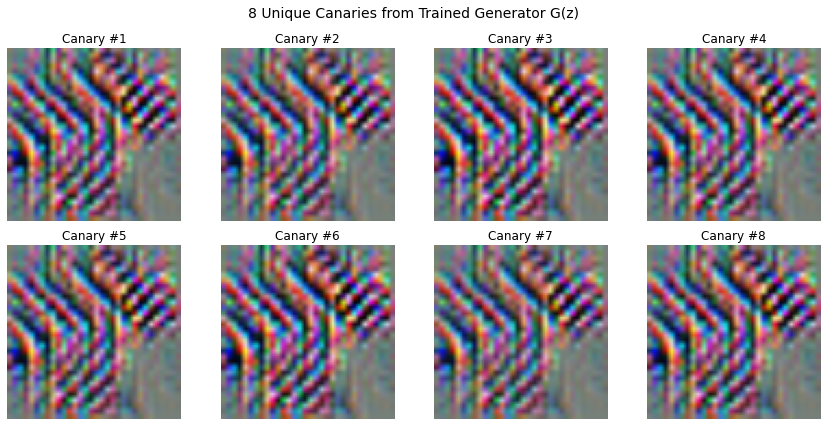


=== Evaluation on hady_test_samples (unique canary per image) ===
  sample.jpg: is_attack = False (unique canary)
  sample2.jpg: is_attack = True (unique canary)
  sample_adv.jpg: is_attack = True (unique canary)


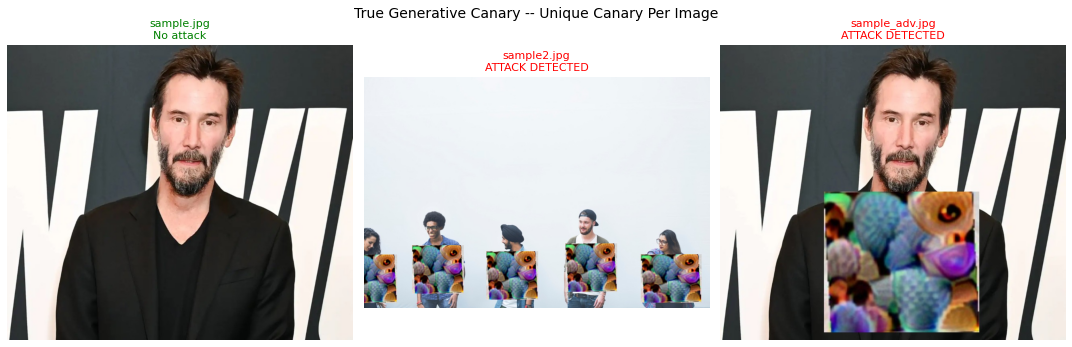

In [29]:
import sys, os, shutil, glob, copy, cv2, torch, random
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace
from copy import deepcopy
from tqdm import tqdm
from torchvision import transforms

sys.path.insert(0, os.path.abspath('..'))
from YOLOv8_Combiner import (
    add_defensivepatch_into_tensor, make_yolo_train_label,
    Yolov8Dataset, Canary, freeze_seed
)
from ObjectDetector.fjn_yolov8 import FJN_YOLOv8 as YOLOv8

# =============================================
#  FLAGS
# =============================================
retrain_from_scratch = False
canary_cls_id = 22
EPOCHS = 50
BATCH_SIZE = 5
LR = 1e-3
WEIGHT = 2.0          # lambda_c
SAVE_EVERY = 10       # checkpoint every N epochs

# =============================================
#  PATHS
# =============================================
work_dir = './generative_canary_training'
ckpt_dir = os.path.join(work_dir, 'checkpoints')
final_ckpt = os.path.join(ckpt_dir, f'generator_epoch_{EPOCHS:03d}.pt')

# =============================================
#  STEP 0: Clean slate or resume
# =============================================
if retrain_from_scratch and os.path.exists(work_dir):
    shutil.rmtree(work_dir)
    print(f"Cleared {work_dir}/")

os.makedirs(ckpt_dir, exist_ok=True)

# =============================================
#  Check if training is already done
# =============================================
if os.path.exists(final_ckpt) and not retrain_from_scratch:
    print(f"Found final checkpoint at {final_ckpt} -- skipping training.")
    print("Set retrain_from_scratch = True to force retrain.\n")

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    generator = GenerativeCanary().to(device)
    ckpt = torch.load(final_ckpt, map_location=device)
    generator.load_state_dict(ckpt['generator_state_dict'])
    generator.eval()
    print(f"Loaded trained generator (epoch {ckpt['epoch']})")

else:
    # ==============================================
    #  STEP 1: Setup
    # ==============================================
    print("=== True Generative Canary Training ===")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    freeze_seed(301)

    cfg = SimpleNamespace(
        canary_cls_id=canary_cls_id, canary_size=80,
        img_size=640, person_conf=0.05, overlap_thresh=0.4,
        defensive_patch_location='cc', eval_no_overlap=True,
        margin_size=0, faster=False,
    )

    # Detector (frozen)
    print("Loading YOLOv8 detector...")
    detector = YOLOv8()
    for p in detector.model.parameters():
        p.requires_grad = False

    # Generator
    generator = GenerativeCanary().to(device)
    print(f"Generator parameters: {sum(p.numel() for p in generator.parameters()):,}")

    # Optimizer & scheduler on generator weights only
    optimizer = optim.Adam(generator.parameters(), lr=LR, amsgrad=True)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    # Dataloader
    train_dataset = Yolov8Dataset(
        '../Data/traineval/VOC07_YOLOv8/train_120/benign',
        '../Data/traineval/VOC07_YOLOv8/train_120/adversarial',
        '../Data/traineval/VOC07_YOLOv8/train_120/benign_label',
        cfg.img_size
    )
    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True
    )

    # ==============================================
    #  STEP 2: Resume from checkpoint if available
    # ==============================================
    start_epoch = 1
    existing_ckpts = sorted(glob.glob(os.path.join(ckpt_dir, 'generator_epoch_*.pt')))
    if existing_ckpts and not retrain_from_scratch:
        latest_ckpt = existing_ckpts[-1]
        ckpt = torch.load(latest_ckpt, map_location=device)
        generator.load_state_dict(ckpt['generator_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        start_epoch = ckpt['epoch'] + 1
        print(f"Resumed from {latest_ckpt} (epoch {ckpt['epoch']})")

    # ==============================================
    #  STEP 3: Training loop
    # ==============================================
    print(f"\nTraining epochs {start_epoch} to {EPOCHS}, batch_size={BATCH_SIZE}, lr={LR}, weight={WEIGHT}")

    t = tqdm(total=EPOCHS - start_epoch + 1, ascii=True)
    for epoch in range(start_epoch, EPOCHS + 1):
        t.set_description(f'gen_canary epoch: {epoch}/{EPOCHS}')
        generator.train()

        for i_batch, (benign_input, benign_label, adv_input) in enumerate(train_loader):
            benign_input = benign_input.cuda()
            adv_input = adv_input.cuda()

            # Sample fresh z for this batch -- one canary shared across the batch
            eta = torch.randn(1, 32, device=device)
            bbox = torch.tensor([[0.3, 0.4, 0.5, 0.8]], device=device)
            z = torch.cat([eta, bbox], dim=1)

            # Generate canary via the generator (gradients flow through this)
            canary_patch = generator(z)  # (1, 3, 80, 80)
            canary_patch_3d = canary_patch.squeeze(0)  # (3, 80, 80)

            # Paste canary into adversarial and benign images
            detector.model.eval()
            adv_with_canary, adv_canary_pos = add_defensivepatch_into_tensor(
                detector, cfg, adv_input, canary_patch_3d, random_palce=True
            )
            benign_with_canary, benign_canary_pos = add_defensivepatch_into_tensor(
                detector, cfg, benign_input, canary_patch_3d, random_palce=True
            )

            # Build YOLO label batches from canary positions
            adv_batch = make_yolo_train_label(adv_with_canary, adv_canary_pos)
            benign_batch = make_yolo_train_label(benign_with_canary, benign_canary_pos)

            # Forward through YOLOv8 in train mode to get loss
            detector.model.train()
            adv_loss, adv_items = detector.model.model(adv_batch)
            benign_loss, benign_items = detector.model.model(benign_batch)

            # FFF canary loss: encourage detection on benign, fragility on adversarial
            loss = WEIGHT * benign_loss - adv_loss

            # Backprop into generator weights
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            t.set_postfix({
                'b_loss': f'{benign_loss.item():.4f}',
                'a_loss': f'{adv_loss.item():.4f}',
                'total': f'{loss.item():.4f}',
            })

        scheduler.step()

        # Save checkpoint
        if epoch % SAVE_EVERY == 0 or epoch == EPOCHS:
            ckpt_path = os.path.join(ckpt_dir, f'generator_epoch_{epoch:03d}.pt')
            torch.save({
                'epoch': epoch,
                'generator_state_dict': generator.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
            }, ckpt_path)
            tqdm.write(f"  Saved checkpoint: {ckpt_path}")

        t.update(1)

    t.close()
    print("Training complete!")
    detector.model.eval()
    generator.eval()

# =============================================
#  STEP 4: Show 8 diverse canaries from trained generator
# =============================================
print("\n=== Trained Generator: 8 Diverse Canaries ===")
generator.eval()
n_show = 8
eta_samples = torch.randn(n_show, 32, device=device)
bbox_samples = torch.tensor([[0.3, 0.4, 0.5, 0.8]], device=device).repeat(n_show, 1)
z_samples = torch.cat([eta_samples, bbox_samples], dim=1)

with torch.no_grad():
    canaries = generator(z_samples)  # (8, 3, 80, 80)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = canaries[i].cpu().permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(f'Canary #{i+1}')
    ax.axis('off')
fig.suptitle('8 Unique Canaries from Trained Generator G(z)', fontsize=14)
plt.tight_layout()
plt.show()

# =============================================
#  STEP 5: Evaluate on hady_test_samples
#  Each image gets a FRESH unique canary
# =============================================
print("\n=== Evaluation on hady_test_samples (unique canary per image) ===")

try:
    detector.model.eval()
except NameError:
    detector = YOLOv8()
    detector.model.eval()

eval_cfg = SimpleNamespace(
    canary_cls_id=canary_cls_id, canary_size=80, img_size=640,
    person_conf=0.05, overlap_thresh=0.4, defensive_patch_location='cc',
    eval_no_overlap=True, margin_size=0, faster=False,
)
canary_eval = Canary(eval_cfg, detector)

test_dir = '../hady_test_samples'
test_images = sorted(os.listdir(test_dir))

fig, axes = plt.subplots(1, len(test_images), figsize=(5 * len(test_images), 5))
if len(test_images) == 1:
    axes = [axes]

for i, fname in enumerate(test_images):
    # Generate a UNIQUE canary for this image
    eta = torch.randn(1, 32, device=device)
    bbox = torch.tensor([[0.3, 0.4, 0.5, 0.8]], device=device)
    z = torch.cat([eta, bbox], dim=1)
    with torch.no_grad():
        canary_patch = generator(z)  # (1, 3, 80, 80)

    # Convert to cv2 format and set as eval canary
    canary_np = (canary_patch[0].cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    canary_bgr = cv2.cvtColor(canary_np, cv2.COLOR_RGB2BGR)
    canary_eval.eval_canary = canary_bgr
    canary_eval.canary_cls_id = canary_cls_id

    img_path = os.path.join(test_dir, fname)
    img_cv = cv2.imread(img_path, 1)
    is_attack = canary_eval.eval_single(img_cv)

    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    result_text = "ATTACK DETECTED" if is_attack else "No attack"
    color = 'red' if is_attack else 'green'
    axes[i].set_title(f'{fname}\n{result_text}', fontsize=11, color=color)
    axes[i].axis('off')
    print(f"  {fname}: is_attack = {is_attack} (unique canary)")

fig.suptitle('True Generative Canary -- Unique Canary Per Image', fontsize=14)
plt.tight_layout()
plt.show()